In [2]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report


seq_len = 30*4
overlap = 0.5
stride = int(seq_len * (1 - overlap))


# データ読み込み関数
def load_session(user="U0101", session="S0100", base_dir="../openpack_subset"):
    def load_atr(sensor):
        path = f"{base_dir}/{user}/atr/{sensor}/{session}.csv"
        df = pd.read_csv(path)
        df["datetime"] = pd.to_datetime(df["unixtime"], unit="ms", utc=True).dt.tz_convert("Asia/Tokyo")
        return df

    # --- センサデータ ---
    df_r = load_atr("atr01")  # 右手
    df_l = load_atr("atr02")  # 左手

    # --- ラベルデータ（operation / action 両方）---
    op_dir = f"{base_dir}/{user}/annotation"
    df_op_lv1 = pd.read_csv(f"{op_dir}/openpack-operations/{session}.csv")  # Lv1
    df_op_lv2 = pd.read_csv(f"{op_dir}/openpack-actions/{session}.csv")     # Lv2

    for df in [df_op_lv1, df_op_lv2]:
        df["start"] = pd.to_datetime(df["start"], format="mixed").dt.tz_convert("Asia/Tokyo")
        df["end"]   = pd.to_datetime(df["end"], format="mixed").dt.tz_convert("Asia/Tokyo")

    return df_r, df_l, df_op_lv1, df_op_lv2





# ウィンドウ分割
def window_split(df_r, df_l, df_op_lv1, df_op_lv2, window_size=256, stride=128):
    df_r = df_r.sort_values("unixtime")
    df_l = df_l.sort_values("unixtime")

    # df = pd.merge_asof(
    #     df_r, df_l,
    #     on="unixtime",
    #     suffixes=("_r", "_l"),
    #     tolerance=20,
    #     direction="nearest"
    # )

    # arr = df[[
    #     #"acc_x_r","acc_y_r","acc_z_r","gyro_x_r","gyro_y_r","gyro_z_r",
    #      "acc_x_l","acc_y_l","acc_z_l","gyro_x_l","gyro_y_l","gyro_z_l"
    # ]].values
    arr = df_l[["acc_x","acc_y","acc_z","gyro_x","gyro_y","gyro_z"]].values

    unixtime = df_l["unixtime"].values

    windows, labels_lv1, labels_lv2 = [], [], []

    for start in range(0, len(arr) - window_size, stride):
        end = start + window_size
        win = arr[start:end].T
        t_ts = pd.to_datetime(unixtime[start + window_size//2], unit="ms", utc=True).tz_convert("Asia/Tokyo")

        # --- Lv1: Operation ---
        op1 = df_op_lv1[(df_op_lv1["start"] <= t_ts) & (t_ts <= df_op_lv1["end"])]
        label_lv1 = op1["operation"].values[0] if len(op1) > 0 else "None"

        # --- Lv2: Action ---
        op2 = df_op_lv2[(df_op_lv2["start"] <= t_ts) & (t_ts <= df_op_lv2["end"])]
        label_lv2 = op2["action"].values[0] if len(op2) > 0 else "None"

        windows.append(win)
        labels_lv1.append(label_lv1)
        labels_lv2.append(label_lv2)

    return np.array(windows), np.array(labels_lv1), np.array(labels_lv2)



# Dataset 定義
class IMUDataset(Dataset):
    def __init__(self, X, y, yy):

        # gyroscope: degrees → radians 
        X = X.copy()
        X[:, 3:6, :] *= np.pi / 180.0
        
        self.X = torch.tensor(X, dtype=torch.float32) # (B, 12, 256)
        self.y = torch.tensor(y, dtype=torch.long)
        self.yy = torch.tensor(yy, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i], self.yy[i]



In [3]:
from torch.utils.data import random_split
from dataclasses import dataclass

@dataclass
class ExperimentConfig:
    model_type: str           # "cnn-linear", "multi-trans"
    pretrain: bool            # SimCLR pretrain
    frozen: bool              # freeze encoder
    lr_type: str              # "uniform" or "layerwise" or "none" (when frozen)
    base_dir: str             # base directory to save results
    save_dir: str           # directory to save results
    seed: int = 0             # random seed

valid_ops = [
    "Picking",
    "Relocate Item Label",
    "Assemble Box",
    "Insert Items",
    "Close Box",
    "Attach Box Label",
    "Scan Label",
    "Attach Shipping Label",
    "Put on Back Table",
    "Fill out Order"
]

def sample_train_windows_by_rate(X, y, yy, rate, seed):
    if rate >= 1.0:
        return X, y, yy

    rng = np.random.default_rng(seed)
    selected_indices = []

    for class_label in np.unique(y):
        class_indices = np.where(y == class_label)[0]
        if len(class_indices) == 0:
            continue

        sample_size = max(1, int(np.floor(rate * len(class_indices))))
        sample_size = min(sample_size, len(class_indices))
        chosen = rng.choice(class_indices, size=sample_size, replace=False)
        selected_indices.append(chosen)

    if len(selected_indices) == 0:
        return X[:0], y[:0], yy[:0]

    selected_indices = np.sort(np.concatenate(selected_indices))
    return X[selected_indices], y[selected_indices], yy[selected_indices]


def build_loaders_for_subject(test_user, users, sessions,
                              window_size=30*4*10,
                              stride_train=30*4*2,
                              stride_test=30*4*1,
                              valid_ratio=0.1,
                              batch_size=32,
                              labeling_rate=1.0,
                              sampling_seed=0,
                              config: ExperimentConfig = None):
    
    if config.model_type == "cnn-linear":
        window_size = 120 * 1
        train_stride = 60 * 1
        test_stride = 120 * 1
    elif config.model_type == "multi-trans":
        window_size = 120 * 10
        train_stride = 120 * 1
        test_stride = 120 * 1
    elif config.model_type == "dcl": #change stride 4->1
        window_size = 120 * 10
        train_stride = 120 * 1 
        test_stride = 120 * 1
    elif config.model_type == "dct":
        window_size = 120 * 10
        train_stride = 120 * 1
        test_stride = 120 * 1

    X_train, y_train, yy_train = [], [], []
    X_test,  y_test,  yy_test  = [], [], []
    train_subject_data = {}
    test_sessions_data = {}


    # --- ユーザごとに読み込む ---
    for user in users:
        for sess in sessions:
            try:
                df_r, df_l, df_op, df_act = load_session(user, sess)
            except FileNotFoundError:
                print(f"File not found: user={user}, session={sess}")
                continue

            # テストユーザ
            if user == test_user:
                X, y, yy = window_split(df_r, df_l, df_op,df_act,
                                    window_size=window_size,
                                    stride=test_stride)
                valid = np.isin(y, valid_ops)
                X_test.append(X[valid])
                y_test.append(y[valid])
                yy_test.append(yy[valid])
                test_sessions_data[sess] = (X[valid], y[valid], yy[valid])

            # 学習ユーザ
            else:
                X, y, yy = window_split(df_r, df_l, df_op,df_act,
                                    window_size=window_size,
                                    stride=train_stride)
                valid = np.isin(y, valid_ops)
                X = X[valid]
                y = y[valid]
                yy = yy[valid]

                if user not in train_subject_data:
                    train_subject_data[user] = {"X": [], "y": [], "yy": []}

                train_subject_data[user]["X"].append(X)
                train_subject_data[user]["y"].append(y)
                train_subject_data[user]["yy"].append(yy)

    # --- subject-wise sampling on train data only ---
    for user in sorted(train_subject_data.keys()):
        X_user = np.concatenate(train_subject_data[user]["X"])
        y_user = np.concatenate(train_subject_data[user]["y"])
        yy_user = np.concatenate(train_subject_data[user]["yy"])

        X_user, y_user, yy_user = sample_train_windows_by_rate(
            X_user, y_user, yy_user, labeling_rate, sampling_seed
        )

        X_train.append(X_user)
        y_train.append(y_user)
        yy_train.append(yy_user)

    # --- 結合 ---
    X_train = np.concatenate(X_train)
    y_train = np.concatenate(y_train)
    yy_train = np.concatenate(yy_train)
    X_test  = np.concatenate(X_test)
    y_test  = np.concatenate(y_test)
    yy_test = np.concatenate(yy_test)

    # label encoding
    le_y = LabelEncoder()
    le_y.fit(np.unique(np.concatenate([y_train, y_test])))
    y_train_enc = le_y.transform(y_train)
    y_test_enc  = le_y.transform(y_test)

    le_yy = LabelEncoder()
    le_yy.fit(np.unique(np.concatenate([yy_train, yy_test])))
    yy_train_enc = le_yy.transform(yy_train)
    yy_test_enc  = le_yy.transform(yy_test) 

    # --- Dataset ---
    train_dataset = IMUDataset(X_train, y_train_enc, yy_train_enc)
    test_dataset  = IMUDataset(X_test,  y_test_enc, yy_test_enc)
    # --- train/valid split ---
    train_len = int(len(train_dataset) * (1 - valid_ratio))
    valid_len = len(train_dataset) - train_len
    train_ds, valid_ds = random_split(
        train_dataset,
        [train_len, valid_len],
        generator=torch.Generator().manual_seed(config.seed)
    )

    # --- DataLoader ---
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)
    #test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    test_loaders = {
    sess: DataLoader(IMUDataset(d[0], le_y.transform(d[1]), le_yy.transform(d[2])),
                     batch_size=batch_size, shuffle=False)
    for sess, d in test_sessions_data.items()
    }


    print(f"[test_user={test_user} | rate={labeling_rate:.2f}] Train={len(train_ds)}, Valid={len(valid_ds)}, Test={len(test_dataset)}")
    print(f"  Classes: {le_y.classes_}")

    return train_loader, valid_loader, test_loaders


[test_user=U0101 | rate=1.00] Train=655, Valid=73, Test=521
  Classes: ['Assemble Box' 'Attach Box Label' 'Attach Shipping Label' 'Close Box'
 'Fill out Order' 'Insert Items' 'Picking' 'Put on Back Table'
 'Relocate Item Label' 'Scan Label']
X_batch shape: torch.Size([32, 6, 1200])
y_batch shape: torch.Size([32])
yy_batch shape: torch.Size([32])


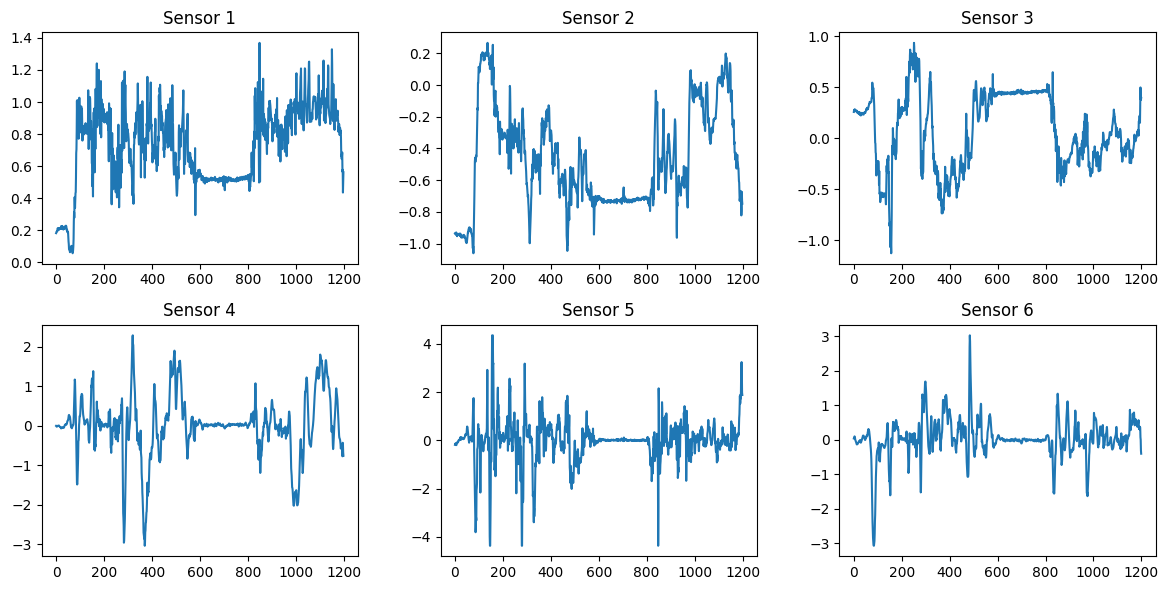

In [4]:
#check batch sample
train_loader, valid_loader, test_loaders = build_loaders_for_subject(
    test_user="U0101",
    users=["U0101","U0102"],
    sessions=["S0100"],
    config=ExperimentConfig(
        model_type="multi-trans",
        pretrain=False,
        frozen=False,
        lr_type="uniform",
        base_dir="",
        save_dir="",
        seed=0  
    ))

for X_batch, y_batch, yy_batch in train_loader:
    print("X_batch shape:", X_batch.shape)  # (B, 12, 256)
    print("y_batch shape:", y_batch.shape)  # (B,)
    print("yy_batch shape:", yy_batch.shape)  # (B,)
    break

#visualize a sample X_batch[0]
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.plot(X_batch[0, i, :].numpy())
    plt.title(f"Sensor {i+1}")
plt.tight_layout()  
plt.show()


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score
import os
import json


device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

def compute_class_weights(train_loader, num_classes):
    counts = torch.zeros(num_classes)

    for _, labels, _ in train_loader:
        for c in range(num_classes):
            counts[c] += (labels == c).sum()

    total = counts.sum()
    counts[counts == 0] = 1  # 0割回避
    weights = total / (num_classes * counts)
    
    return weights                                                                                                                                                                                                                                                                               


# Train one epoch
def train_one_epoch(classifier, loader, optimizer, criterion):
    classifier.train()
    total_loss = 0
    total_n = 0

    for signals, labels, _ in loader:
        signals = signals.to(device)
        labels  = labels.to(device)

        logits, _, _ = classifier(signals)
        
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)
        total_n    += len(labels)

    return total_loss / total_n



# Evaluate
def evaluate(classifier, loader, criterion=None):
    classifier.eval()
    total_loss = 0
    total_n = 0

    Y, P = [], []

    with torch.no_grad():
        for signals, labels, _ in loader:
            signals = signals.to(device)
            labels  = labels.to(device)

            logits, _ , _ = classifier(signals)
            preds  = logits.argmax(dim=1)

            Y.extend(labels.cpu().numpy())
            P.extend(preds.cpu().numpy())

            if criterion is not None:
                loss = criterion(logits, labels)
                total_loss += loss.item() * len(labels)
                total_n    += len(labels)

    if criterion is None:
        return Y, P, None
    else:
        return Y, P, total_loss / total_n

def record_results(test_user, y_true, y_pred,
                           results_dir="results_loso"):
    os.makedirs(results_dir, exist_ok=True)
    save_path = os.path.join(results_dir, f"{test_user}.json")

    result = {
        "user": test_user,
        "y_true": list(map(int, y_true)),
        "y_pred": list(map(int, y_pred))
    }
    with open(save_path, "w") as f:
        json.dump(result, f, indent=2)

    print(f"Saved: {save_path}")


In [6]:
import importlib
import models
importlib.reload(models)
from models import SimCLR, CNN_Encoder, TaskClassifier_DCT, TaskClassifier_Transformer, TaskClassifier_LSTM, TaskClassifier_Linear, TaskClassifier_DCL
from dataclasses import dataclass

@dataclass
class ExperimentConfig:
    model_type: str           # "cnn-linear", "multi-trans"
    pretrain: bool            # SimCLR pretrain
    frozen: bool              # freeze encoder
    lr_type: str              # "uniform" or "layerwise" or "none" (when frozen)
    base_dir: str             # base directory to save results
    save_dir: str             # directory to save results
    seed: int = 0             # random seed

def build_model(config: ExperimentConfig,test_user):
    """
    config.model_type : "cnn-linear" or "multi-trans"
    config.pretrain   : True/False
    config.frozen     : True/False
    """

    # # --- 1. Encoder 作成 ---
    # if config.pretrain:
    #     sim = SimCLR(input_dim=6,seq_len=120,hidden_dim=64,feature_dim=128,projection_dim=64,dropout=0.3)
    #     sim.load_state_dict(torch.load(
    #         #"/home/kisho_ucl/kisho_ws/har_warehouse/model/encoder_100_120w_1112.pth",
    #         #f"/home/kisho_ucl/kisho_ws/har_warehouse/openpack_exp/model/encoder_leave_{test_user}_100.pth",
    #         f"/home/kisho_ucl/kisho_ws/har_warehouse/openpack_exp/model/encoder_leave_all_S100v5_100.pth", #共通 #前の実験
    #         #f"/home/kisho_ucl/kisho_ws/har_warehouse/openpack_exp/model/encoder_leave_all_S100v7_100.pth",#
    #         #f"/home/kisho_ucl/kisho_ws/har_warehouse/openpack_exp/model/encoder_baseline_leave_all_S100v7_100.pth",#
    #         #f"/home/kisho_ucl/kisho_ws/har_warehouse/openpack_exp/model/encoder_ucihar_leave_all_S100v7_100.pth",
    
    #         map_location="cpu"
    #     ))
    #     encoder = sim.encoder
    #     print(f"Loaded pretrained encoder leaving out user {test_user}")
    # else:
    #     encoder = CNN_Encoder(input_dim=6, seq_len=120, hidden_dim=64, feature_dim=128, dropout=0.3)
    #     print("Created new encoder.")
     # --- 1. Encoder 作成 ---
    if config.pretrain_type == "None":
        encoder = CNN_Encoder(input_dim=6, seq_len=120, hidden_dim=64, feature_dim=128, dropout=0.3)
        print("Created new encoder.")

    else:
        sim = SimCLR(input_dim=6, seq_len=120, hidden_dim=64, feature_dim=128, projection_dim=64, dropout=0.3)

        # ===== モデルごとのパス分岐 =====
        if config.pretrain_type == "csshar":
            path = f"/home/kisho_ucl/kisho_ws/har_warehouse/openpack_exp/model/encoder_ucihar_leave_all_S100v7_100.pth"

        elif config.pretrain_type == "mysimclr":
            path = f"/home/kisho_ucl/kisho_ws/har_warehouse/openpack_exp/model/encoder_mysimclr_leave_all_S100v7_100.pth"

        elif config.pretrain_type == "mysimclr2":
            path = f"/home/kisho_ucl/kisho_ws/har_warehouse/openpack_exp/model/encoder_mysimclr2_leave_all_S100v7_100.pth"
            #path = f"/home/kisho_ucl/kisho_ws/har_warehouse/openpack_exp/model/encoder_mysimclr_leave_all_S100v7_100.pth"

        else:
            raise ValueError(f"Unknown pretrain_type: {config.pretrain_type}")

        sim.load_state_dict(torch.load(path, map_location="cpu"))
        encoder = sim.encoder

        print(f"Loaded pretrained encoder: {config.pretrain_type}")

    # --- Freeze設定 ---
    if config.frozen:
        for p in encoder.parameters():
            p.requires_grad = False

        print("Encoder is frozen.")
    else:
        print("Encoder is trainable.")

    # --- 2. Model selection ---
    if config.model_type == "cnn-linear":
        model = TaskClassifier_Linear(   # ← linear head なら別クラスでもOK
            encoder=encoder,
            feature_dim=128,
            hidden_dim=64,
            num_classes=10,
            dropout=0.1,
            freeze_encoder=config.frozen
        )
        return model

    elif config.model_type == "multi-trans":
        model = TaskClassifier_Transformer(
            encoder=encoder,
            feature_dim=128,
            window_len=120,
            overlap=0.5,
            num_heads=4,
            num_layers=3,
            num_classes=10,
            freeze_encoder=config.frozen
        )
        return model
    elif config.model_type == "dcl":
        model = TaskClassifier_DCL(
            input_dim=6,
            hidden_dim=64,
            feature_dim=128,
            lstm_hidden=128,
            num_layers=2,
            num_classes=10,
            dropout=0.1,
        )
        return model
    
    elif config.model_type == "dct":
        model = TaskClassifier_DCT(
            input_dim=6,
            hidden_dim=64,
            feature_dim=128,
            num_heads=4,
            num_layers=3,
            num_classes=10,
            dropout=0.1,
        )
        return model

    else:
        raise ValueError(f"Unknown model_type: {config.model_type}")
    
def build_optimizer(model, config: ExperimentConfig):

    # =============================
    # 1. encoder を固定する場合
    # ============================= 
    # change lr to 1e-3
    if config.frozen:
        print("Optimizer: frozen encoder → uniform LR 1e-3")
        params = [p for p in model.parameters() if p.requires_grad]
        return torch.optim.Adam(params, lr=1e-3)


    # =============================
    # 2. uniform LR
    # =============================
    if config.lr_type == "uniform":
        print("Optimizer: uniform lr=1e-3")
        return torch.optim.Adam(model.parameters(), lr=1e-3)


    # =============================
    # 3. layer-wise LR
    # =============================
    elif config.lr_type == "layerwise":

        encoder_lr = 1e-4
        head_lr = 1e-3

        if isinstance(model, TaskClassifier_Transformer):
            print("Optimizer: layerwise (Transformer)")
            return torch.optim.Adam([
                {"params": model.encoder.parameters(),      "lr": encoder_lr},
                {"params": model.transformer.parameters(),  "lr": head_lr}, #out weight decay
                {"params": model.classifier.parameters(),   "lr": head_lr},
            ])

        elif isinstance(model, TaskClassifier_LSTM):
            print("Optimizer: layerwise (LSTM)")
            return torch.optim.Adam([
                {"params": model.encoder.parameters(),      "lr": encoder_lr},
                {"params": model.lstm.parameters(),         "lr": head_lr}, # out weight decay
                {"params": model.classifier.parameters(),   "lr": head_lr},
            ])
        elif isinstance(model, TaskClassifier_Linear):
            print("Optimizer: layerwise (Linear)")
            return torch.optim.Adam([
                {"params": model.encoder.parameters(),      "lr": encoder_lr},
                {"params": model.classifier.parameters(),   "lr": head_lr}, # out weight decay
            ])
        else:
            raise ValueError("Unknown model architecture for layerwise LR")

    else:
        raise ValueError(f"Unknown lr_type {config.lr_type}")




In [7]:
from copy import deepcopy
import os
import json


class EarlyStopping:
    def __init__(self, patience=5, delta=0.0):
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.counter = 0
        self.early_stop = False
        self.best_state = None
        self.best_epoch = 0

    def __call__(self, epoch, val_loss, model):
        # 初回、または改善したとき
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.best_state = deepcopy(model.state_dict())
            self.best_epoch = epoch
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True



In [8]:
import models
importlib.reload(models)
from models import SimCLR, CNN_Encoder, TaskClassifier_Transformer, TaskClassifier_LSTM, TaskClassifier_DCT
from dataclasses import dataclass
import random

@dataclass
class ExperimentConfig:
    model_type: str           # "cnn-linear", "multi-trans"
    #pretrain: bool            # SimCLR pretrain
    pretrain_type: str   # "none", "csshar", "mysimclr", "mysimclr2"
    frozen: bool              # freeze encoder
    lr_type: str              # "uniform" or "layerwise" or "none" (when frozen)
    base_dir: str             # base directory to save results
    save_dir: str           # directory to save results
    seed: int = 0             # random seed

# Reset random seeds
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# LOSO
def run_loso_one(
        train_loader, valid_loader, test_loader,
        weight_tensor, test_user="UNKNOWN",
        max_epochs=30, patience=5,
        config: ExperimentConfig = None):

    # Set random seed
    set_seed(config.seed)

    # モデル構築
    classifier = build_model(config,test_user=test_user).to(device)
    optimizer = build_optimizer(classifier, config)

    weight_tensor = weight_tensor.to(device)
    criterion = nn.CrossEntropyLoss(weight=weight_tensor)

    num_classes = 10

    # Early stopping
    early_stopper = EarlyStopping(patience=patience)

    # Training loop
    for epoch in range(1, max_epochs + 1):

        train_loss = train_one_epoch(classifier, train_loader, optimizer, criterion)
        _, _, valid_loss = evaluate(classifier, valid_loader, criterion)
        Y_tmp, P_tmp, test_loss = evaluate(classifier, test_loader, criterion)
        f1_tmp = f1_score(Y_tmp, P_tmp, average="macro")

        print(
            f"[Epoch {epoch}/{max_epochs}] "
            f"Train={train_loss:.4f} | "
            f"Valid={valid_loss:.4f} | "
            f"Test={test_loss:.4f} | F1={f1_tmp:.4f}"
        )

        # early stopping check
        early_stopper(epoch, valid_loss, classifier)
        if early_stopper.early_stop:
            print("Early stopping.")
            break

    # Load best model
    classifier.load_state_dict(early_stopper.best_state)

    Y, P, _ = evaluate(classifier, test_loader, criterion)
    final_f1 = f1_score(Y, P, average="macro")

    print(f"[SAVE PATH] {config.save_dir}/{test_user}.json")


    print(f"[{test_user}] Final F1 = {final_f1:.4f} | BestEpoch={early_stopper.best_epoch}")

    record_results(test_user, Y, P, results_dir=config.save_dir)

    return final_f1, Y, P, classifier

In [16]:
# ==========================================
# 実験設定
# ==========================================

configs = [
    ExperimentConfig("cnn-linear", "None", False, "uniform",   "T1_cnn", ""),
    #ExperimentConfig("cnn-linear", "csshar", True, "uniform",   "T2_precnn_std", ""),
    ExperimentConfig("cnn-linear", "mysimclr2", True, "uniform",   "T3_precnn_adj", ""),
    #ExperimentConfig("dct", "None",  False, "uniform", "T4_dct", ""),
    #ExperimentConfig("multi-trans", "None", False, "uniform",   "T5_cnn-transformer", ""),
    #ExperimentConfig("multi-trans", "csshar", True, "uniform",   "T6_precnn-transformer_std", ""),
    #ExperimentConfig("multi-trans", "mysimclr2", True, "uniform",   "T7_precnn-transformer_adj", "")
]

seeds = [0]
#labeling_rates = [0.05,0.10,0.25,0.50,0.75,1.00]
labeling_rates = [0.01,0.05,0.1,0.25,0.5,0.75,1.00]
sampling_seed = 0

users = ["U0101", "U0102", "U0103", "U0104", "U0105",
         "U0106", "U0107", "U0108", "U0109", "U0110",
         "U0111", "U0201", "U0206", "U0207", "U0208",
         "U0209"]

# users = ["U0101", "U0102", "U0103", "U0104", "U0105"]

sessions = ["S0100"]
num_classes = 10  # ← Operation Recognition 用

# ==========================================
# 実験ループ（SEED → RATE → CONFIG → LOSO）
# ==========================================
results = {}

for seed in seeds:
    print(f"\n=========== SEED {seed} ===========")

    for rate in labeling_rates:
        print(f"\n----- Labeling rate: {rate:.2f} -----")
        results[rate] = {}

        for cfg in configs[:]:
            print("===================================")
            print(f" Variant: {cfg.base_dir}")
            print("===================================")

            cfg.seed = seed

            for test_user in users:
                set_seed(seed)

                train_loader, valid_loader, test_loaders = build_loaders_for_subject(
                    test_user=test_user,
                    users=users,
                    sessions=sessions,
                    window_size=30*4*10,
                    stride_train=30*4*2,
                    stride_test=30*4*1,
                    valid_ratio=0.1,
                    batch_size=32,
                    labeling_rate=rate,
                    sampling_seed=sampling_seed,
                    config=cfg
                )

                weight_tensor = compute_class_weights(train_loader, num_classes=num_classes)
                weight_tensor = weight_tensor.to(device)

                fold_scores = []
                for sess, loader in test_loaders.items():
                    save_dir_sess = os.path.join(
                        "results_loso_rate",
                        f"seed{seed}",
                        f"rate{int(rate * 100):03d}",
                        cfg.base_dir,
                        sess,
                    )
                    cfg.save_dir = save_dir_sess
                    os.makedirs(save_dir_sess, exist_ok=True)

                    f1, Y, P, classifier = run_loso_one(
                        train_loader,
                        valid_loader,
                        loader,
                        weight_tensor=weight_tensor,
                        test_user=test_user,
                        max_epochs=30,
                        patience=5,
                        config=cfg,
                    )
                    fold_scores.append(float(f1))

                subject_score = float(np.mean(fold_scores))
                results[rate][test_user] = subject_score
                print(f"  Seed={seed}, Rate={rate:.2f}, User={test_user}, F1={subject_score:.4f}")

        rate_mean_f1 = float(np.mean(list(results[rate].values())))
        print(f"[SUMMARY] Seed={seed}, Rate={rate:.2f}, mean_f1={rate_mean_f1:.4f}")

    rate_summary_df = pd.DataFrame([
        {
            "seed": seed,
            "rate": rate,
            "mean_f1": float(np.mean(list(results[rate].values()))),
            "n_folds": len(results[rate]),
        }
        for rate in labeling_rates
    ])

    rate_vs_f1 = rate_summary_df["mean_f1"].to_numpy()
    print(rate_summary_df)
    print("rate_vs_f1 =", rate_vs_f1)

    summary_dir = os.path.join("results_loso_rate", f"seed{seed}")
    os.makedirs(summary_dir, exist_ok=True)
    rate_summary_df.to_csv(os.path.join(summary_dir, "rate_summary.csv"), index=False)
    with open(os.path.join(summary_dir, "rate_summary.json"), "w") as fp:
        json.dump({
            "seed": seed,
            "labeling_rates": labeling_rates,
            "results": {str(rate): results[rate] for rate in labeling_rates},
            "mean_f1": {str(rate): float(np.mean(list(results[rate].values()))) for rate in labeling_rates},
        }, fp, indent=2)




=========== SEED 0 ===========

----- Labeling rate: 0.01 -----
 Variant: T1_cnn
[test_user=U0101 | rate=0.01] Train=148, Valid=17, Test=529
  Classes: ['Assemble Box' 'Attach Box Label' 'Attach Shipping Label' 'Close Box'
 'Fill out Order' 'Insert Items' 'Picking' 'Put on Back Table'
 'Relocate Item Label' 'Scan Label']
Created new encoder.
Encoder is trainable.
Optimizer: uniform lr=1e-3
[Epoch 1/30] Train=2.2782 | Valid=2.2890 | Test=2.2954 | F1=0.0178
[Epoch 2/30] Train=2.1706 | Valid=2.2618 | Test=2.2548 | F1=0.1150
[Epoch 3/30] Train=2.0752 | Valid=2.2111 | Test=2.1874 | F1=0.1614
[Epoch 4/30] Train=1.9798 | Valid=2.1380 | Test=2.0892 | F1=0.1648
[Epoch 5/30] Train=1.8915 | Valid=2.0532 | Test=1.9853 | F1=0.1401
[Epoch 6/30] Train=1.7773 | Valid=2.0053 | Test=1.9016 | F1=0.1654
[Epoch 7/30] Train=1.6787 | Valid=1.9526 | Test=1.8389 | F1=0.2003
[Epoch 8/30] Train=1.5931 | Valid=1.9362 | Test=1.8179 | F1=0.1814
[Epoch 9/30] Train=1.4568 | Valid=1.9786 | Test=1.7797 | F1=0.2191
[Ep

,model,rate,mean_score,std_score,n_runs,mean_subjects,train_percent
0,T1_cnn,0.01,0.241107,0.0,1,16.0,1.0
1,T1_cnn,0.05,0.317591,0.0,1,16.0,5.0
2,T1_cnn,0.10,0.372276,0.0,1,16.0,10.0
3,T1_cnn,0.25,0.459501,0.0,1,16.0,25.0
4,T1_cnn,0.50,0.525430,0.0,1,16.0,50.0
5,T1_cnn,0.75,0.557226,0.0,1,16.0,75.0
6,T1_cnn,1.00,0.568430,0.0,1,16.0,100.0
7,T3_precnn_adj,0.01,0.407988,0.0,1,16.0,1.0
8,T3_precnn_adj,0.05,0.467471,0.0,1,16.0,5.0
9,T3_precnn_adj,0.10,0.494532,0.0,1,16.0,10.0


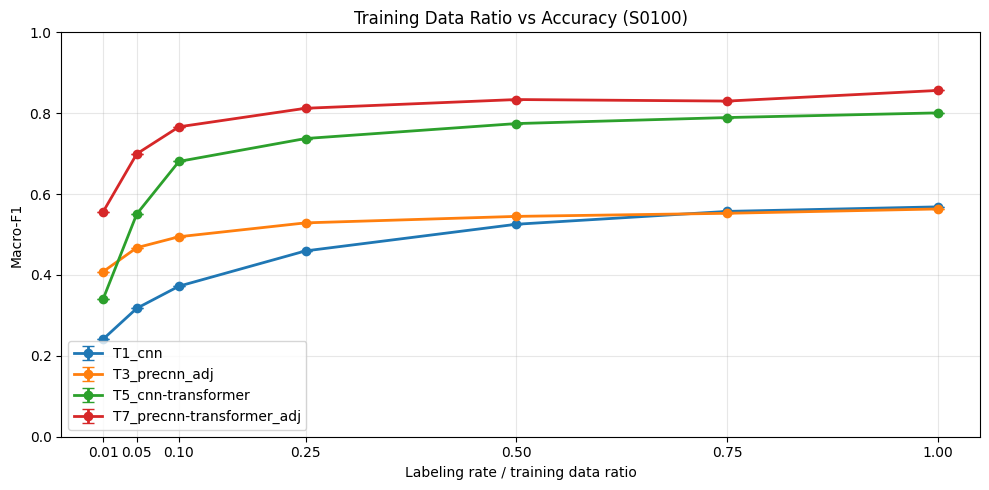

In [17]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from IPython.display import display


def collect_rate_results(root_dir="results_loso_rate", session_name=None, average="macro"):
    rows = []

    for seed_name in sorted(os.listdir(root_dir)):
        seed_dir = os.path.join(root_dir, seed_name)
        if not os.path.isdir(seed_dir) or not seed_name.startswith("seed"):
            continue

        for rate_name in sorted(os.listdir(seed_dir)):
            rate_dir = os.path.join(seed_dir, rate_name)
            if not os.path.isdir(rate_dir) or not rate_name.startswith("rate"):
                continue

            try:
                rate_value = int(rate_name.replace("rate", "")) / 100.0
            except ValueError:
                continue

            for model_name in sorted(os.listdir(rate_dir)):
                model_dir = os.path.join(rate_dir, model_name)
                if not os.path.isdir(model_dir):
                    continue

                per_subject_scores = []

                for sess_name in sorted(os.listdir(model_dir)):
                    if session_name is not None and sess_name != session_name:
                        continue

                    sess_dir = os.path.join(model_dir, sess_name)
                    if not os.path.isdir(sess_dir):
                        continue

                    for fname in sorted(os.listdir(sess_dir)):
                        if not fname.endswith(".json"):
                            continue

                        json_path = os.path.join(sess_dir, fname)
                        with open(json_path, "r") as fp:
                            record = json.load(fp)

                        y_true = np.array(record["y_true"])
                        y_pred = np.array(record["y_pred"])
                        per_subject_scores.append(f1_score(y_true, y_pred, average=average))

                if len(per_subject_scores) == 0:
                    continue

                rows.append(
                    {
                        "seed": seed_name,
                        "rate": rate_value,
                        "model": model_name,
                        "score": float(np.mean(per_subject_scores)),
                        "n_subjects": len(per_subject_scores),
                    }
                )

    return pd.DataFrame(rows)


results_root = "results_loso_rate"
session_name = "S0100"
score_df = collect_rate_results(results_root, session_name=session_name, average="macro")

if score_df.empty:
    raise ValueError(f"No results found under: {results_root}")

summary_df = (
    score_df.groupby(["model", "rate"], as_index=False)
    .agg(
        mean_score=("score", "mean"),
        std_score=("score", "std"),
        n_runs=("score", "size"),
        mean_subjects=("n_subjects", "mean"),
    )
    .sort_values(["model", "rate"])
)

summary_df["std_score"] = summary_df["std_score"].fillna(0.0)
summary_df["train_percent"] = summary_df["rate"] * 100.0

display(summary_df)

plt.figure(figsize=(10, 5))
for model_name, group_df in summary_df.groupby("model"):
    group_df = group_df.sort_values("rate")
    plt.errorbar(
        group_df["rate"],
        group_df["mean_score"],
        yerr=group_df["std_score"],
        marker="o",
        linewidth=2,
        capsize=4,
        label=model_name,
    )

rate_values = sorted(summary_df["rate"].unique())
plt.xticks(rate_values, [f"{rate:.2f}" for rate in rate_values])
plt.ylim(0.0, 1.0)
plt.xlabel("Labeling rate / training data ratio")
plt.ylabel("Macro-F1")
plt.title(f"Training Data Ratio vs Accuracy ({session_name})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
